In [1]:
print("Hello Bro, Project Started 🚀")

Hello Bro, Project Started 🚀


In [2]:
# variables
a = 10

# if condition
if a > 5:
    print("Big")

# loop
for i in range(5):
    print(i)

# function
def add(x, y):
    return x + y

Big
0
1
2
3
4


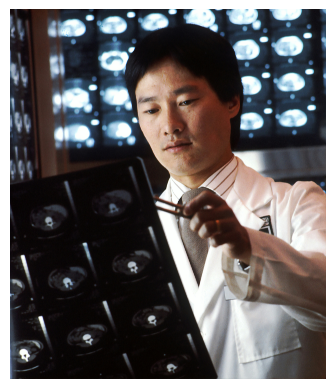

In [7]:
import cv2
import matplotlib.pyplot as plt
import requests
import numpy as np

url = "https://images.unsplash.com/photo-1581595219315-a187dd40c322"

resp = requests.get(url)
image = np.asarray(bytearray(resp.content), dtype="uint8")

img = cv2.imdecode(image, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

In [8]:
!pip install tensorflow

In [9]:
from tensorflow.keras.applications import ResNet50

model = ResNet50(weights='imagenet')
print("Model Loaded ✅")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model Loaded ✅


In [15]:
import os

# Create folders
os.makedirs('/content/dataset/normal', exist_ok=True)
os.makedirs('/content/dataset/risk', exist_ok=True)

print("Folders Created ✅")

Folders Created ✅


In [18]:
import os
import numpy as np
import cv2

# Create folders
os.makedirs('/content/dataset/normal', exist_ok=True)
os.makedirs('/content/dataset/risk', exist_ok=True)

# Create random images
for i in range(20):
    img = np.random.randint(0, 255, (224,224,3), dtype=np.uint8)
    cv2.imwrite(f'/content/dataset/normal/img_{i}.jpg', img)

for i in range(20):
    img = np.random.randint(0, 255, (224,224,3), dtype=np.uint8)
    cv2.imwrite(f'/content/dataset/risk/img_{i}.jpg', img)

print("Dataset Created ✅")

Dataset Created ✅


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_datagen.flow_from_directory(
    '/content/dataset',
    target_size=(224,224),
    batch_size=4,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    '/content/dataset',
    target_size=(224,224),
    batch_size=4,
    class_mode='binary',
    subset='validation'
)

Found 32 images belonging to 2 classes.
Found 8 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled ✅")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Compiled ✅


In [22]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 841ms/step - accuracy: 0.6250 - loss: 3.1342 - val_accuracy: 0.5000 - val_loss: 0.7609
Epoch 2/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 754ms/step - accuracy: 0.5000 - loss: 0.6826 - val_accuracy: 0.5000 - val_loss: 0.7017
Epoch 3/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 926ms/step - accuracy: 0.7812 - loss: 0.5375 - val_accuracy: 0.5000 - val_loss: 0.8167


In [23]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load any image from dataset
img = image.load_img('/content/dataset/normal/img_0.jpg', target_size=(224,224))

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("High Risk ⚠️")
else:
    print("Low Risk ✅")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Low Risk ✅


In [24]:
if prediction[0][0] > 0.5:
    print("⚠️ Prediction: HIGH RISK")
else:
    print("✅ Prediction: LOW RISK")

✅ Prediction: LOW RISK


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


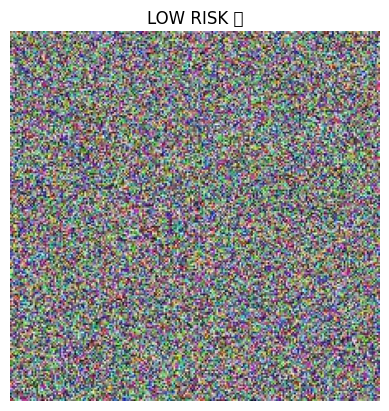

In [25]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis('off')

if prediction[0][0] > 0.5:
    plt.title("HIGH RISK ⚠️")
else:
    plt.title("LOW RISK ✅")

plt.show()